In [1]:
# Breast Cancer · цена FP высока (скрининг)

#Контекст: модель работает как первичный скрининг. Ложноположительные = здоровая
#пациентка отправлена на биопсию → деньги, стресс
#Целевые метрики: Precision, Specificity, F0.5
#Почему: не пугаем зря; лучше пропустить 1–2 случая в скрининге (они попадут во второе мнение), чем гонять на биопсию всех подряд

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer                          # ← вот этот импорт потерялся
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'breast_cancer_fp'

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/breast_cancer_fp
ART_DIR  : /app/artifacts/classification/breast_cancer_fp


In [3]:
def predict_at_threshold(p_positive, threshold, positive_label=1):
    """
    Бинарное предсказание по вероятности positive-класса.
    p_positive — P(positive | x). Возвращает положительный класс там, где
    p_positive >= threshold, иначе — противоположный.
    """
    p_positive = np.asarray(p_positive)
    other = 1 - positive_label
    return np.where(p_positive >= threshold, positive_label, other).astype(int)


def all_metrics(y_true, y_pred, y_proba=None, positive_label=1):
    """
    Метрики классификации. positive_label явно управляет всеми per-class
    метриками (precision/recall/fbeta/specificity/sensitivity/ROC/PR).
    """
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),

        # ── per-class именно для positive_label ──
        'precision_pos':     precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'recall_pos':        recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'f1_pos':            f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'f0.5_pos':          fbeta_score(y_true, y_pred, beta=0.5, pos_label=positive_label, zero_division=0),
        'f2_pos':            fbeta_score(y_true, y_pred, beta=2.0, pos_label=positive_label, zero_division=0),
    }

    if y_proba is None:
        return m

    p = y_proba[:, positive_label] if y_proba.ndim == 2 else y_proba
    y_bin = (np.asarray(y_true) == positive_label).astype(int)

    m['roc_auc'] = roc_auc_score(y_bin, p)
    m['pr_auc']  = average_precision_score(y_bin, p)

    # явный порядок labels, чтобы [tn, fp, fn, tp] соответствовали positive_label
    labels = [0, 1] if positive_label == 1 else [1, 0]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()
    m['specificity'] = tn / (tn + fp) if (tn + fp) else 0.0
    m['sensitivity'] = tp / (tp + fn) if (tp + fn) else 0.0
    m['n_tp'], m['n_fp'], m['n_fn'], m['n_tn'] = int(tp), int(fp), int(fn), int(tn)

    return m


def metrics_table(results: dict) -> pd.DataFrame:
    return pd.DataFrame(results).T.round(4)


def plot_confusion(cm, labels, title, ax=None):
    ax = ax if ax is not None else plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

In [4]:
## 1. Загрузка данных

#Датасет Breast Cancer Wisconsin — встроен в sklearn
#569 образцов, 30 числовых признаков
#Класс 0 = **malignant** (злокачественная опухоль), класс 1 = **benign** (доброкачественная)

#В скрининге «положительный» результат = подозрение на рак = класс 0. Значит `positive_label = 0`

In [5]:
bc = load_breast_cancer(as_frame=True)

X = bc.data.values
y = bc.target.values                         # 0 = malignant, 1 = benign

FEATURES = list(bc.data.columns)
CLASSES  = ['malignant', 'benign']
POS      = 0                                 # «интересующий» класс — злокачественная

df = pd.DataFrame(X, columns=FEATURES).assign(target=y)

print('X shape      :', X.shape)
print('Класс 0 (malignant):', (y == 0).sum())
print('Класс 1 (benign)   :', (y == 1).sum())
print('prevalence of positive:', f'{(y == POS).mean():.4f}')
df.head()

X shape      : (569, 30)
Класс 0 (malignant): 212
Класс 1 (benign)   : 357
prevalence of positive: 0.3726


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
## 2. EDA — баланс классов и распределение признаков

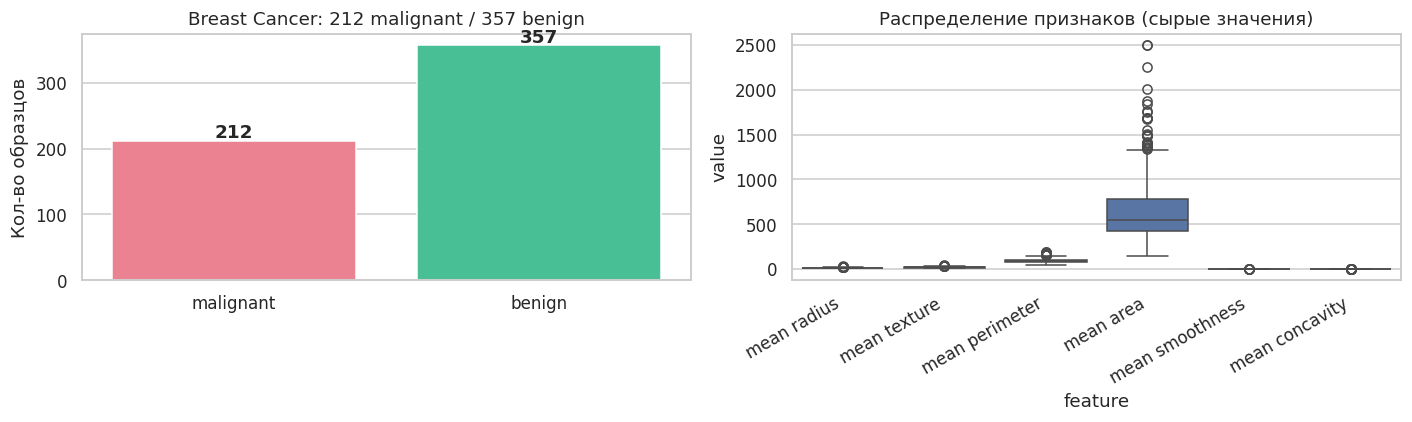

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 2.1 Баланс классов
counts = df.target.value_counts().sort_index()
sns.barplot(x=CLASSES, y=counts.values,
            palette=['#fb7185', '#34d399'], ax=axes[0])
axes[0].set_title('Breast Cancer: 212 malignant / 357 benign')
axes[0].set_ylabel('Кол-во образцов')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2.2 Распределение нескольких признаков
sample_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean concavity']
df_melt = df[sample_feats].melt(var_name='feature', value_name='value')
sns.boxplot(data=df_melt, x='feature', y='value', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Распределение признаков (сырые значения)')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [8]:
## 3. Train / test split (стратифицированный)

#Стратификация сохраняет пропорции классов в обеих выборках.Размер теста — 25%

In [9]:
# Сначала отделяем TEST — он запечатан до самого конца.
X_tr_full, X_test, y_tr_full, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
# Из остатка — VALIDATION для подбора порога.
X_train, X_val, y_train, y_val = train_test_split(
    X_tr_full, y_tr_full, test_size=0.20, stratify=y_tr_full, random_state=SEED
)

print('train:', X_train.shape, '| val:', X_val.shape, '| test:', X_test.shape)
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name:5s}: {dict(zip(*np.unique(yy, return_counts=True)))}')

train: (340, 30) | val: (86, 30) | test: (143, 30)
  train: {np.int64(0): np.int64(127), np.int64(1): np.int64(213)}
  val  : {np.int64(0): np.int64(32), np.int64(1): np.int64(54)}
  test : {np.int64(0): np.int64(53), np.int64(1): np.int64(90)}


In [10]:
## 4. Модели + sweep по порогу

##Ключевая идея: не просто обучаем и берём `predict()` с порогом 0.5, а **сдвигаем порог вверх** — модель реже говорит «подозрение».

##Три порога:
##- 0.5 — стандарт;
##- 0.7 — умеренная строгость;
##- 0.9 — говорим «рак» только при очень высокой уверенности.

In [11]:
models = {
    'LogReg': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=2000, random_state=SEED)),
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, random_state=SEED, n_jobs=-1
    ),
}

# --- Naive baseline ---
naive = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_naive = naive.predict(X_test)
results = {'Naive (majority)': all_metrics(y_test, y_naive, positive_label=POS)}

# --- CV по train (5 фолдов) с корректной логикой порога ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}
for name, m in models.items():
    scores = []
    for tr, va in cv.split(X_train, y_train):
        mm = clone(m).fit(X_train[tr], y_train[tr])
        p  = mm.predict_proba(X_train[va])[:, POS]
        yp = predict_at_threshold(p, 0.5, POS)
        scores.append(fbeta_score(y_train[va], yp, beta=0.5, pos_label=POS))
    cv_results[name] = (float(np.mean(scores)), float(np.std(scores)))
    print(f'{name:12s}  CV F0.5 (pos) = {cv_results[name][0]:.4f} '
          f'± {cv_results[name][1]:.4f}')

# --- обучение на всём train ---
fitted, probas, preds = {}, {}, {}
for name, m in models.items():
    m.fit(X_train, y_train)
    fitted[name] = m
    probas[name] = m.predict_proba(X_test)
    preds[name]  = m.predict(X_test)
    assert list(m.classes_) == [0, 1], f'{name}: classes_={m.classes_}'

# --- метрики на TEST при дефолтном пороге (predict использует 0.5 по argmax) ---
for name, m in models.items():
    results[name] = all_metrics(
        y_test, preds[name], probas[name], positive_label=POS
    )

print()
print(f'Naive F0.5 (pos) = {results["Naive (majority)"]["f0.5_pos"]:.4f}')
print()
metrics_table(results)

LogReg        CV F0.5 (pos) = 0.9703 ± 0.0173
RandomForest  CV F0.5 (pos) = 0.9354 ± 0.0518

Naive F0.5 (pos) = 0.0000



,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,...,f0.5_pos,f2_pos,roc_auc,pr_auc,specificity,sensitivity,n_tp,n_fp,n_fn,n_tn
Naive (majority),0.6294,0.5000,0.3147,0.5000,0.3863,0.4862,0.3399,0.4473,0.0000,0.0000,...,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LogReg,0.9860,0.9850,0.9850,0.9850,0.9850,0.9860,0.9850,0.9850,0.9700,0.9700,...,0.9811,0.9811,0.9975,0.9964,0.9889,0.9811,52.0,1.0,1.0,89.0
RandomForest,0.9580,0.9512,0.9587,0.9512,0.9547,0.9579,0.9570,0.9525,0.9098,0.9094,...,0.9533,0.9316,0.9925,0.9885,0.9778,0.9245,49.0,2.0,4.0,88.0


In [12]:
## 5. Threshold sweep — как меняются Precision / Recall при сдвиге порога

##Строим 40 точек от 0.05 до 0.95
##Для каждой считаем все метрики
##Ищем порог, где F0.5 максимальна — это компромисс «precision важнее recall, но совсем без recall не хочется»

In [13]:
model_lr = fitted['LogReg']

# Порог подбираем ТОЛЬКО на валидации.
p_val = model_lr.predict_proba(X_val)[:, POS]

sweep_rows = []
for t in np.linspace(0.05, 0.95, 40):
    y_pred = predict_at_threshold(p_val, t, POS)          # ← было (p_val >= t).astype(int)
    m = all_metrics(y_val, y_pred, np.c_[p_val, 1 - p_val], positive_label=POS)
    m['threshold'] = t
    sweep_rows.append(m)

sweep = pd.DataFrame(sweep_rows).set_index('threshold')
sweep.round(4).head(10)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,...,f0.5_pos,f2_pos,roc_auc,pr_auc,specificity,sensitivity,n_tp,n_fp,n_fn,n_tn
threshold,,,,,,,,,,,,,,,,,,,,,
0.050000,0.9070,0.9259,0.9000,0.9259,0.9044,0.9084,0.8999,0.9151,0.8255,0.8106,...,0.8333,0.9524,1.0,1.0,0.8519,1.0,32,8,0,46
0.073077,0.9535,0.9630,0.9444,0.9630,0.9514,0.9540,0.9467,0.9577,0.9072,0.9029,...,0.9091,0.9756,1.0,1.0,0.9259,1.0,32,4,0,50
0.096154,0.9651,0.9722,0.9571,0.9722,0.9633,0.9654,0.9593,0.9683,0.9292,0.9267,...,0.9302,0.9816,1.0,1.0,0.9444,1.0,32,3,0,51
0.119231,0.9651,0.9722,0.9571,0.9722,0.9633,0.9654,0.9593,0.9683,0.9292,0.9267,...,0.9302,0.9816,1.0,1.0,0.9444,1.0,32,3,0,51
0.142308,0.9651,0.9722,0.9571,0.9722,0.9633,0.9654,0.9593,0.9683,0.9292,0.9267,...,0.9302,0.9816,1.0,1.0,0.9444,1.0,32,3,0,51
0.165385,0.9767,0.9815,0.9706,0.9815,0.9754,0.9769,0.9724,0.9789,0.9520,0.9509,...,0.9524,0.9877,1.0,1.0,0.9630,1.0,32,2,0,52
0.188462,0.9767,0.9815,0.9706,0.9815,0.9754,0.9769,0.9724,0.9789,0.9520,0.9509,...,0.9524,0.9877,1.0,1.0,0.9630,1.0,32,2,0,52
0.211538,0.9767,0.9815,0.9706,0.9815,0.9754,0.9769,0.9724,0.9789,0.9520,0.9509,...,0.9524,0.9877,1.0,1.0,0.9630,1.0,32,2,0,52
0.234615,0.9767,0.9815,0.9706,0.9815,0.9754,0.9769,0.9724,0.9789,0.9520,0.9509,...,0.9524,0.9877,1.0,1.0,0.9630,1.0,32,2,0,52


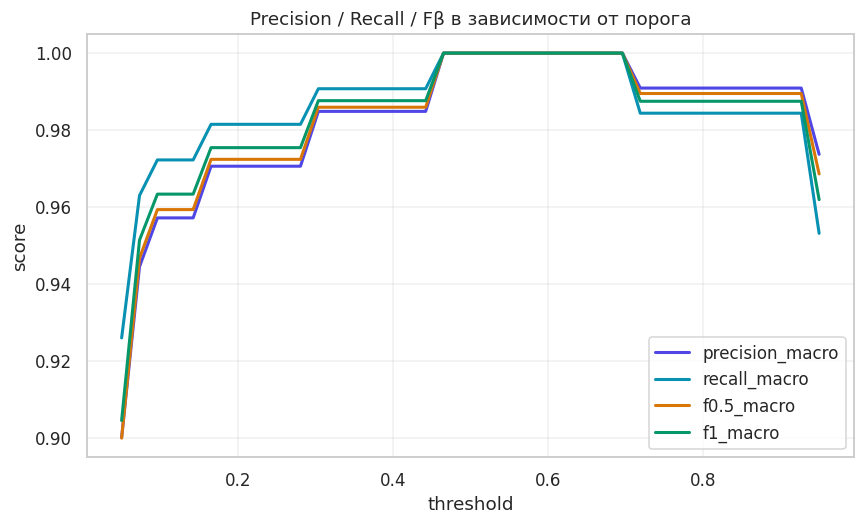

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, color in [
    ('precision_macro', '#4f46e5'),
    ('recall_macro',    '#0891b2'),
    ('f0.5_macro',      '#d97706'),
    ('f1_macro',        '#059669'),
]:
    ax.plot(sweep.index, sweep[col], label=col, color=color, linewidth=2)

ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.set_title('Precision / Recall / Fβ в зависимости от порога')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig(ART_DIR / 'threshold_sweep.png', bbox_inches='tight')
plt.show()

In [15]:
# Hero-метрика — F0.5 именно для malignant
HERO = 'f0.5_pos'

opt_thr = sweep[HERO].idxmax()
print('Оптимум по F0.5 (positive=malignant) — на VALIDATION:')
for k in ['precision_pos', 'recall_pos', HERO, 'specificity', 'sensitivity',
          'n_fp', 'n_fn']:
    print(f'  {k:14s} = {sweep.loc[opt_thr, k]}')

# --- Финальная честная оценка на TEST ---
p_test = model_lr.predict_proba(X_test)[:, POS]
y_pred_test = predict_at_threshold(p_test, opt_thr, POS)     # ← было (p_test >= opt_thr).astype(int)
test_metrics = all_metrics(y_test, y_pred_test,
                           np.c_[p_test, 1 - p_test], positive_label=POS)
print('\nФинальные метрики на TEST:')
print(pd.Series(test_metrics).round(4))

Оптимум по F0.5 (positive=malignant) — на VALIDATION:
  precision_pos  = 1.0
  recall_pos     = 1.0
  f0.5_pos       = 1.0
  specificity    = 1.0
  sensitivity    = 1.0
  n_fp           = 0
  n_fn           = 0

Финальные метрики на TEST:
accuracy              0.9790
balanced_accuracy     0.9795
precision_macro       0.9759
recall_macro          0.9795
f1_macro              0.9776
f1_weighted           0.9791
f0.5_macro            0.9765
f2_macro              0.9787
mcc                   0.9553
kappa                 0.9552
precision_pos         0.9630
recall_pos            0.9811
f1_pos                0.9720
f0.5_pos              0.9665
f2_pos                0.9774
roc_auc               0.9975
pr_auc                0.9964
specificity           0.9778
sensitivity           0.9811
n_tp                 52.0000
n_fp                  2.0000
n_fn                  1.0000
n_tn                 88.0000
dtype: float64


In [16]:
## 6. Confusion matrix для оптимального порога

#Сравним с дефолтным 0.5 — увидим, как меняется картина ошибок.

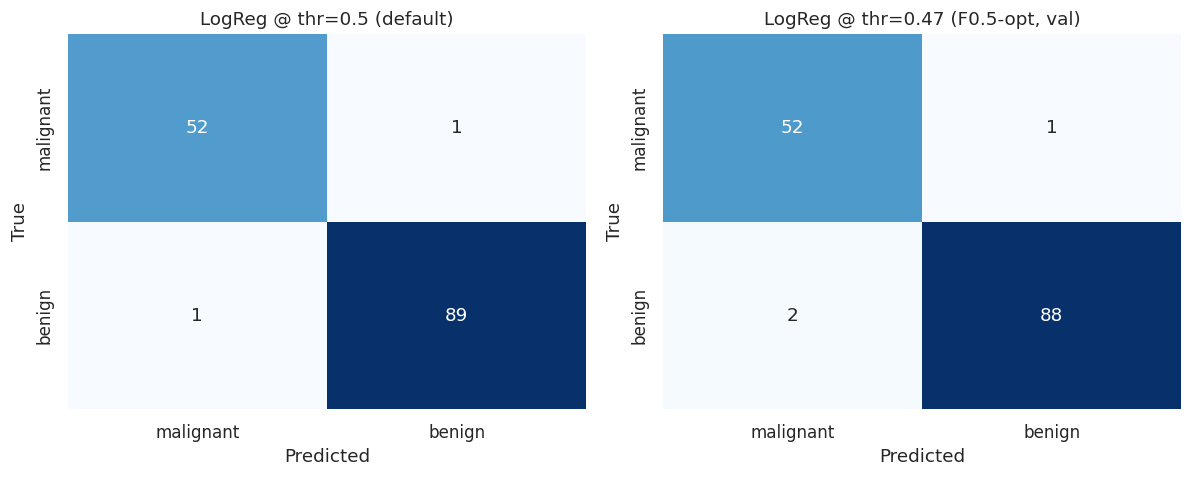

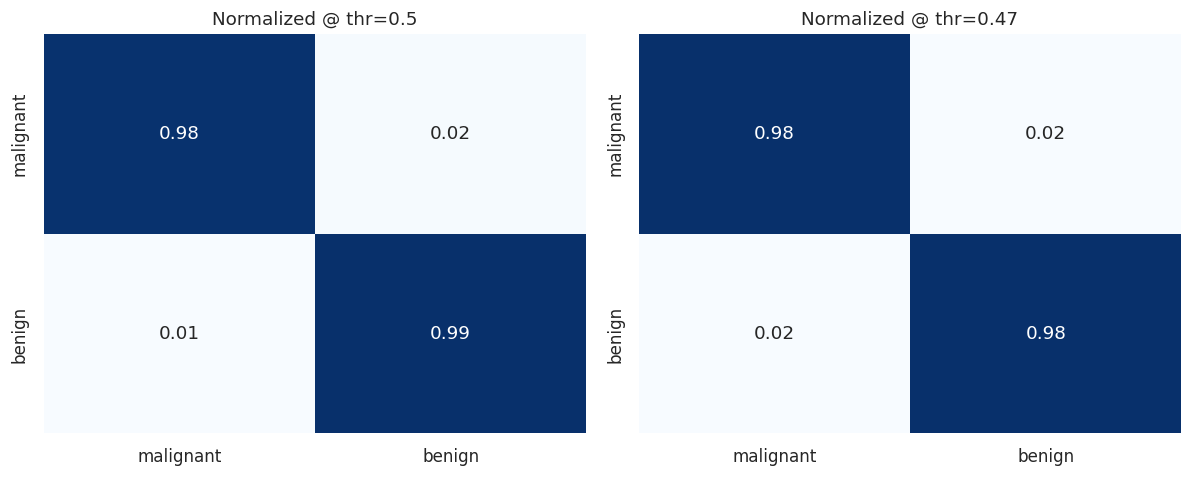

At optimal threshold 0.47:
  TP (malignant→malignant) = 52
  FN (malignant→benign)    = 1
  FP (benign→malignant)    = 2   ← то, что нам дорого
  TN (benign→benign)       = 88


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

y_pred_05  = predict_at_threshold(p_test, 0.5,     POS)
y_pred_opt = predict_at_threshold(p_test, opt_thr, POS)

# confusion_matrix явно с labels=[0,1] — [malignant, benign] как строки/столбцы
cm_05  = confusion_matrix(y_test, y_pred_05,  labels=[0, 1])
cm_opt = confusion_matrix(y_test, y_pred_opt, labels=[0, 1])

plot_confusion(cm_05,  CLASSES, 'LogReg @ thr=0.5 (default)', axes[0])
plot_confusion(cm_opt, CLASSES, f'LogReg @ thr={opt_thr:.2f} (F0.5-opt, val)', axes[1])
plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_optimal.png', bbox_inches='tight')
plt.show()

# нормализованные
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm_05  / cm_05.sum(axis=1, keepdims=True),  annot=True, fmt='.2f',
            cmap='Blues', cbar=False, xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Normalized @ thr=0.5')
sns.heatmap(cm_opt / cm_opt.sum(axis=1, keepdims=True), annot=True, fmt='.2f',
            cmap='Blues', cbar=False, xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title(f'Normalized @ thr={opt_thr:.2f}')
plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_normalized.png', bbox_inches='tight')
plt.show()

# ── счётчики: POS=0, поэтому TP = cm[0,0], FN = cm[0,1], FP = cm[1,0], TN = cm[1,1] ──
tp, fn = int(cm_opt[0, 0]), int(cm_opt[0, 1])
fp, tn = int(cm_opt[1, 0]), int(cm_opt[1, 1])
print(f'At optimal threshold {opt_thr:.2f}:')
print(f'  TP (malignant→malignant) = {tp}')
print(f'  FN (malignant→benign)    = {fn}')
print(f'  FP (benign→malignant)    = {fp}   ← то, что нам дорого')
print(f'  TN (benign→benign)       = {tn}')

In [18]:
## 7. ROC-кривая и PR-кривая

#ROC — устойчивый обзор, но при небольшом дисбалансе (212/357) более информативна PR-кривая. Показываем обе для полноты

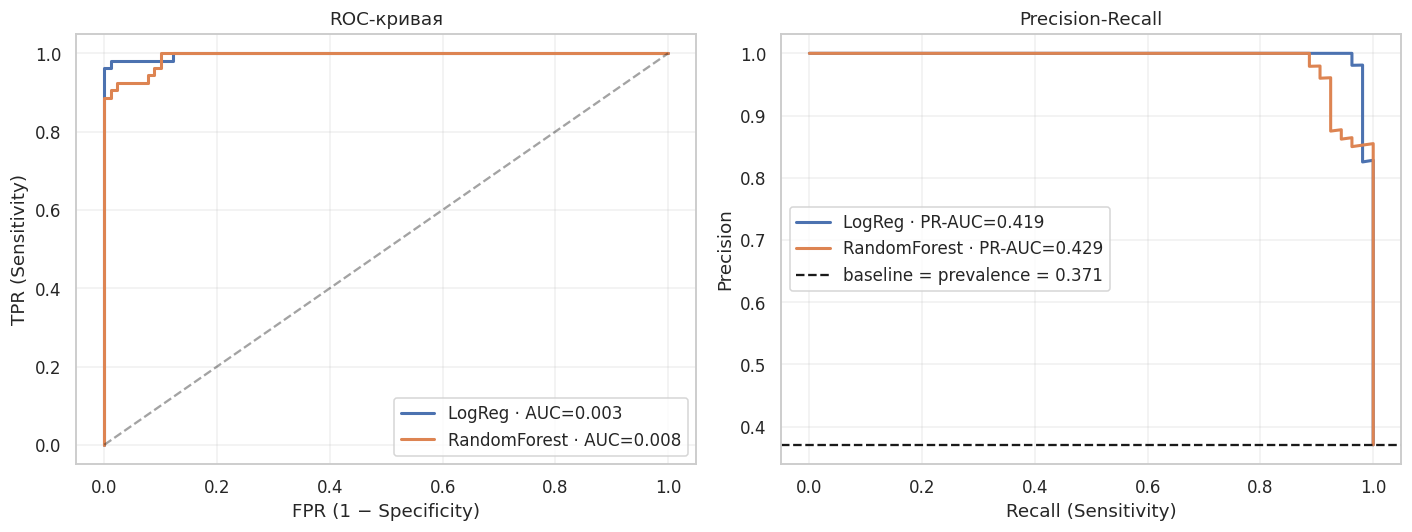

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in probas.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba[:, 0], pos_label=0)
    auc = roc_auc_score(y_test, proba[:, 0])
    axes[0].plot(fpr, tpr, label=f'{name} · AUC={auc:.3f}', linewidth=2)

    # PR
    pr, rc, _ = precision_recall_curve(y_test, proba[:, 0], pos_label=0)
    ap = average_precision_score(y_test, proba[:, 0])
    axes[1].plot(rc, pr, label=f'{name} · PR-AUC={ap:.3f}', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR (1 − Specificity)')
axes[0].set_ylabel('TPR (Sensitivity)')
axes[0].set_title('ROC-кривая')
axes[0].legend()

axes[1].axhline((y_test == 0).mean(), color='k', ls='--',
                label=f'baseline = prevalence = {(y_test == 0).mean():.3f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'roc_pr.png', bbox_inches='tight')
plt.show()

In [20]:
## 8. Вывод

#Что мы увидели:

#1. При дефолтном пороге 0.5 модель даёт **больше ложных тревог**, чем нужно
#2. Поднимая порог до 0.7–0.9, мы увеличиваем **Precision** (меньше ложных биопсий), но Recall падает — часть раковых клеток пропускаем
#3. Оптимум по **F0.5** — там, где Precision уже высокая, а Recall ещё приемлем

# Выбор метрики обоснован бизнес-контекстом:

#- Мы намеренно жертвуем частью Recall — риск пропуска покрывается вторым этапом (гистология, повторное обследование)
#- F0.5 штрафует FP вдвое сильнее, чем FN → правильная метрика для «мягкого скрининга»
#- Accuracy здесь не главное — она высокая у всех вариантов и не различает модели по риску

# Что сохраняем:
#- Пайплайн LogReg, обученный на train
#- Оптимальный порог `opt_thr`, найденный по F0.5
#- Метаданные: метрики, seed, список признаков, классы

In [21]:
model_path = MODEL_DIR / 'breast_cancer_fp.joblib'
meta_path  = MODEL_DIR / f'breast_cancer_fp_{datetime.now():%Y%m%d_%H%M}.json'

artifact = {
    'pipeline':       model_lr,
    'threshold':      float(opt_thr),
    'threshold_source': 'validation',
    'positive_label': 0,
    'classes':        CLASSES,
}
joblib.dump(artifact, model_path)

meta = {
    'task': 'breast_cancer_fp',
    'model': 'LogReg',
    'description': 'Скрининг: минимизируем FP, целевая метрика F0.5',
    'threshold': float(opt_thr),
    'threshold_source': 'validation',
    'features': FEATURES,
    'classes': CLASSES,
    'positive_label': 0,
    'metrics_on_validation': sweep.loc[opt_thr].round(4).to_dict(),
    'metrics_on_test':       {k: round(v, 4) for k, v in test_metrics.items()},
    'cv_f0.5_mean': float(cv_results['LogReg'][0]),
    'cv_f0.5_std':  float(cv_results['LogReg'][1]),
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))
print('saved model →', model_path)
print('saved meta  →', meta_path)

saved model → /app/models/classification/breast_cancer_fp/breast_cancer_fp.joblib
saved meta  → /app/models/classification/breast_cancer_fp/breast_cancer_fp_20261006_1418.json


In [22]:
sweep.round(6).to_csv(ART_DIR / 'threshold_sweep.csv')
metrics_table(results).to_csv(ART_DIR / 'metrics_all_models.csv')

# JSON-версия метрик — удобно читать программно
(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print('  ', p.name)

artifacts → /app/artifacts/classification/breast_cancer_fp
   confusion_normalized.png
   confusion_optimal.png
   eda.png
   metrics_all_models.csv
   metrics_all_models.json
   report.json
   results.json
   roc_pr.png
   threshold_sweep.csv
   threshold_sweep.png


In [23]:
## 9. Перезагрузка модели и проверка

## Убеждаемся, что артефакт из `models/classification/breast_cancer_fp/breast_cancer_fp.joblib`работает как оригинал: те же предсказания, те же метрики

In [24]:
# 25 — reload
art = joblib.load(model_path)
print('positive_label:', art['positive_label'])
print('threshold     :', art['threshold'])
print('threshold src :', art['threshold_source'])

p_reload = art['pipeline'].predict_proba(X_test)[:, art['positive_label']]
y_pred_reload = predict_at_threshold(p_reload, art['threshold'], art['positive_label'])
reload_metrics = all_metrics(y_test, y_pred_reload,
                             np.c_[p_reload, 1 - p_reload],
                             positive_label=art['positive_label'])

for k, v in test_metrics.items():
    assert abs(reload_metrics[k] - v) < 1e-9, (k, reload_metrics[k], v)
print('OK: reload совпадает с финальной test-оценкой')

positive_label: 0
threshold     : 0.46538461538461534
threshold src : validation
OK: reload совпадает с финальной test-оценкой


In [25]:
# 26 — демо на одном сэмпле
art = joblib.load(model_path)
sample = X_test[0:1]
true_label = y_test[0]

p_mal = art['pipeline'].predict_proba(sample)[0, art['positive_label']]
pred_label = art['positive_label'] if p_mal >= art['threshold'] \
             else 1 - art['positive_label']

print(f'Истинный класс : {CLASSES[true_label]}')
print(f'P(malignant)   : {p_mal:.4f}')
print(f'Порог          : {art["threshold"]:.2f}')
print(f'Предсказание   : {CLASSES[pred_label]}')
print(f'Решение        : {"отправить на биопсию" if pred_label == 0 else "не отправлять"}')

Истинный класс : benign
P(malignant)   : 0.0472
Порог          : 0.47
Предсказание   : benign
Решение        : не отправлять


In [26]:
## 10. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, fbeta_score,
)

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

def _parse_model_key(key, default_thr=0.5):
    """'LogReg' → ('LogReg', 0.5); 'LogReg @thr=0.05' → ('LogReg', 0.05)."""
    if ' @thr=' in key:
        mn, thr_str = key.split(' @thr=')
        return mn, float(thr_str)
    return key, default_thr

# ---------- защита ----------
assert 'X_val' in dir() and 'y_val' in dir(), \
    'Нужны X_val/y_val — сначала обнови exec 9 (split с валидацией)'
assert 'opt_thr' in dir(), 'Нужен opt_thr из exec 16'
assert 'predict_at_threshold' in dir(), 'Нужен predict_at_threshold из exec 3'

HERO_METRIC = 'f0.5_pos'
NAIVE_NAME  = 'Naive (majority)'

# ---------- Naive baseline ----------
if NAIVE_NAME not in results:
    from sklearn.dummy import DummyClassifier
    _naive   = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
    _y_naive = _naive.predict(X_test)
    results[NAIVE_NAME] = all_metrics(y_test, _y_naive, positive_label=POS)

# ---------- CV-сводка по F0.5 (fallback, если ещё не посчитана) ----------
if 'cv_results' not in dir():
    from sklearn.base import clone
    from sklearn.model_selection import StratifiedKFold
    _cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_results = {}
    for name, m in models.items():
        scores = []
        for tr, va in _cv.split(X_train, y_train):
            mm = clone(m).fit(X_train[tr], y_train[tr])
            p  = mm.predict_proba(X_train[va])[:, POS]
            yp = predict_at_threshold(p, 0.5, POS)
            scores.append(fbeta_score(y_train[va], yp, beta=0.5, pos_label=POS))
        cv_results[name] = (float(np.mean(scores)), float(np.std(scores)))

# ---------- финальная test-оценка LogReg на opt_thr ----------
p_test = fitted['LogReg'].predict_proba(X_test)[:, POS]
y_opt_pred = predict_at_threshold(p_test, opt_thr, POS)
test_metrics = all_metrics(
    y_test, y_opt_pred,
    np.c_[p_test, 1 - p_test], positive_label=POS,
)

# ---------- добавляем конфигурацию с выбранным порогом в results ----------
opt_name = f'LogReg @thr={float(opt_thr):g}'
results[opt_name]  = test_metrics
preds[opt_name]    = y_opt_pred
probas[opt_name]   = np.c_[p_test, 1 - p_test]

best_name = opt_name
best_res  = results[best_name]

# ---------- базовые статистики ----------
DATASET_STATS = {
    'n_samples':  int(len(X)),
    'n_features': int(len(FEATURES)),
    'n_classes':  int(len(CLASSES)),
    'n_train':    int(len(X_train)),
    'n_val':      int(len(X_val)),
    'n_test':     int(len(X_test)),
}

counts_all  = {cls: int((y == i).sum())      for i, cls in enumerate(CLASSES)}
counts_test = {cls: int((y_test == i).sum()) for i, cls in enumerate(CLASSES)}

ratio = max(counts_all.values()) / max(min(counts_all.values()), 1)
TARGET_STATS = {
    'class_distribution':      counts_all,
    'class_distribution_test': counts_test,
    'is_balanced':             bool(ratio < 1.1),
    'imbalance_ratio':         float(ratio),
    'positive_label':          int(POS),
    'positive_class':          CLASSES[POS],
    'prevalence_positive':     float((y == POS).mean()),
}

# ---------- baseline отдельным блоком ----------
baseline_block = {
    'name': NAIVE_NAME,
    'metrics': {
        k: float(v) for k, v in results[NAIVE_NAME].items()
        if isinstance(v, (int, float, np.integer, np.floating))
    },
}

# ---------- блок обученных моделей ----------
models_block = []
for name, m in results.items():
    if name == NAIVE_NAME:
        continue

    model_name, thr = _parse_model_key(name, default_thr=0.5)

    y_proba = probas[model_name]
    y_pred  = predict_at_threshold(y_proba[:, POS], thr, POS)
    y_conf  = np.max(y_proba, axis=1)

    cls_report = classification_report(
        y_test, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    per_class = {
        cls: {
            'precision': float(cls_report[cls]['precision']),
            'recall':    float(cls_report[cls]['recall']),
            'f1':        float(cls_report[cls]['f1-score']),
            'support':   int(cls_report[cls]['support']),
        } for cls in CLASSES
    }

    # confusion matrix — порядок [malignant, benign]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tp_mal, fn_mal = int(cm[0, 0]), int(cm[0, 1])
    fp_mal, tn_ben = int(cm[1, 0]), int(cm[1, 1])

    y_bin   = (y_test == POS).astype(int)
    roc_auc = float(roc_auc_score(y_bin, y_proba[:, POS]))
    pr_auc  = float(average_precision_score(y_bin, y_proba[:, POS]))

    mean_conf   = float(np.mean(y_conf))
    median_conf = float(np.median(y_conf))

    entry = {
        'name':        name,
        'model':       model_name,
        'threshold':   thr,
        'is_best':     name == best_name,
        'is_deployed': name == best_name,
        'metrics': {
            k: float(v) for k, v in m.items()
            if isinstance(v, (int, float, np.integer, np.floating))
        },
        'per_class':          per_class,
        'confusion_matrix':   cm.tolist(),
        'confusion_counts': {
            'tp_malignant': tp_mal,
            'fn_malignant': fn_mal,
            'fp_benign':    fp_mal,
            'tn_benign':    tn_ben,
        },
        'roc_auc':           roc_auc,
        'pr_auc':            pr_auc,
        'mean_confidence':   mean_conf,
        'median_confidence': median_conf,
    }

    m_obj = fitted[model_name]
    if hasattr(m_obj, 'feature_importances_'):
        fi = m_obj.feature_importances_
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, fi)],
            key=lambda x: x['value'], reverse=True,
        )
    elif hasattr(m_obj, 'named_steps') and 'm' in m_obj.named_steps \
         and hasattr(m_obj.named_steps['m'], 'coef_'):
        coef = m_obj.named_steps['m'].coef_
        if coef.ndim == 2:
            coef = coef[0]
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(abs(c))} for f, c in zip(FEATURES, coef)],
            key=lambda x: x['value'], reverse=True,
        )

    models_block.append(entry)

best_entry = next(mb for mb in models_block if mb['name'] == best_name)

# ---------- диагностика ----------
print('models_block:')
for mb in models_block:
    print(f"  {mb['name']:25s} thr={mb['threshold']:.3f} "
          f"f0.5_pos={mb['metrics']['f0.5_pos']:.4f} "
          f"is_deployed={mb['is_deployed']}")

# ---------- by_metric ----------
metric_keys = [
    'accuracy', 'balanced_accuracy',
    'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted',
    'f0.5_macro', 'f2_macro',
    'precision_pos', 'recall_pos', 'f1_pos', 'f0.5_pos', 'f2_pos',
    'mcc', 'kappa', 'roc_auc', 'pr_auc',
    'specificity', 'sensitivity',
]
by_metric = {}
for k in metric_keys:
    cands = [(n, results[n][k]) for n in results
             if n != NAIVE_NAME and k in results[n]]
    if cands:
        by_metric[k] = max(cands, key=lambda t: t[1])[0]

# ---------- error_by_class ----------
best_pred = preds[best_name]
best_conf = np.max(probas[best_name], axis=1)

error_by_class = {}
for i, cls in enumerate(CLASSES):
    mask = (y_test == i)
    err  = float(np.mean(best_pred[mask] != i))
    error_by_class[cls] = {
        'support':    int(mask.sum()),
        'error_rate': err,
        'accuracy':   1.0 - err,
    }

# ---------- threshold sweep ----------
threshold_sweep = {
    'model':             'LogReg',
    'sweep_source':      'validation',
    'optimal_threshold': float(opt_thr),
    'thresholds':        [float(t) for t in sweep.index],
    'precision_pos':     [float(v) for v in sweep['precision_pos']],
    'recall_pos':        [float(v) for v in sweep['recall_pos']],
    'f0.5_pos':          [float(v) for v in sweep['f0.5_pos']],
    'f1_pos':            [float(v) for v in sweep['f1_pos']],
    'specificity':       [float(v) for v in sweep['specificity']],
    'sensitivity':       [float(v) for v in sweep['sensitivity']],
}

# ---------- sample predictions ----------
correct_idx = np.where(best_pred == y_test)[0]
wrong_idx   = np.where(best_pred != y_test)[0]

fp_idx = np.where((y_test == 1) & (best_pred == 0))[0]
fn_idx = np.where((y_test == 0) & (best_pred == 1))[0]

if len(correct_idx):
    correct_sorted = correct_idx[np.argsort(-best_conf[correct_idx])][:5]
else:
    correct_sorted = correct_idx

if len(wrong_idx):
    wrong_sorted = wrong_idx[np.argsort(-best_conf[wrong_idx])][:5]
else:
    wrong_sorted = wrong_idx

def _make_sample(idx):
    yt, yp = int(y_test[idx]), int(best_pred[idx])
    if   yt == 1 and yp == 0: et = 'fp'
    elif yt == 0 and yp == 1: et = 'fn'
    else:                     et = 'correct'
    return {
        'features':   {f: float(v) for f, v in zip(FEATURES, X_test[idx])},
        'true':       CLASSES[yt],
        'predicted':  CLASSES[yp],
        'correct':    bool(yt == yp),
        'error_type': et,
        'confidence': float(best_conf[idx]),
        'proba':      {cls: float(p) for cls, p in zip(CLASSES, probas[best_name][idx])},
    }

sample_predictions = (
    [_make_sample(int(i)) for i in correct_sorted] +
    [_make_sample(int(i)) for i in wrong_sorted]
)

# ---------- headline diagnostics ----------
mal = best_entry['per_class']['malignant']
ben = best_entry['per_class']['benign']

diag = {
    'is_balanced':         bool(TARGET_STATS['is_balanced']),
    'prevalence_positive': float(TARGET_STATS['prevalence_positive']),

    'accuracy_vs_balanced_accuracy_gap':
        float(abs(best_res['accuracy'] - best_res['balanced_accuracy'])),
    'accuracy_vs_f1_macro_gap':
        float(abs(best_res['accuracy'] - best_res['f1_macro'])),
    'accuracy_vs_f0.5_pos_gap':
        float(abs(best_res['accuracy'] - best_res['f0.5_pos'])),

    'mcc':         float(best_res['mcc']),
    'kappa':       float(best_res['kappa']),
    'roc_auc':     float(best_res['roc_auc']),
    'pr_auc':      float(best_res['pr_auc']),
    'specificity': float(best_res['specificity']),
    'sensitivity': float(best_res['sensitivity']),

    'best_threshold':   float(opt_thr),
    'threshold_source': 'validation',
    'cv_f0.5_mean':     float(cv_results['LogReg'][0]),
    'cv_f0.5_std':      float(cv_results['LogReg'][1]),

    'test_f0.5_pos':       float(test_metrics['f0.5_pos']),
    'fp_count_at_optimal': int(len(fp_idx)),
    'fn_count_at_optimal': int(len(fn_idx)),
    'fp_fn_ratio':         float(len(fp_idx) / max(len(fn_idx), 1)),
    'n_errors_on_test':    int(len(wrong_idx)),

    'metrics_are_consistent':
        bool(abs(best_res['accuracy'] - best_res['balanced_accuracy']) < 0.05),

    'naive_accuracy':   float(results[NAIVE_NAME]['accuracy']),
    'naive_f0.5_pos':   float(results[NAIVE_NAME]['f0.5_pos']),
}

# ---------- charts ----------
charts = {}
for candidate in [
    'eda.png',
    'threshold_sweep.png',
    'confusion_optimal.png',
    'confusion_normalized.png',
    'roc_pr.png',
]:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
report = {
    'meta': {
        'task':     'breast_cancer_fp',
        'title':    'Breast Cancer · FP дорогой (скрининг)',
        'subtitle': 'Ложная тревога дороже пропуска — hero-метрика F0.5 (malignant)',
        'dataset':  'sklearn.datasets.load_breast_cancer',
        'target':   'diagnosis',
        'target_unit':   '',
        'target_format': 'category',
        'classes':  CLASSES,
        'features': FEATURES,
        'seed':     SEED,
        'generated_at': datetime.now().isoformat(),
        **DATASET_STATS,
        'target_stats': TARGET_STATS,
        'narrative': {
            'context': (
                'Breast Cancer Wisconsin: 569 образцов, 30 числовых признаков. '
                '212 malignant / 357 benign — классы умеренно несбалансированы '
                '(prevalence malignant ≈ 0.37). Модель работает как первый этап '
                'скрининга: FP = здоровая пациентка отправлена на биопсию '
                '(деньги + стресс), FN = пропущенный рак (риск для жизни). '
                'В скрининге мы намеренно допускаем некоторый рост FN ради резкого '
                'снижения FP — пропущенные случаи ловит второй этап (гистология, '
                'повторное обследование).'
            ),
            'hero_metric': 'F0.5 (positive = malignant)',
            'why_not_accuracy': (
                'Accuracy здесь вводит в заблуждение: при imbalance ≈ 1.68:1 модель '
                'может показывать приемлемую точность, но при этом пугать или '
                'пропускать рак. F0.5 для положительного класса (malignant) '
                'смещает фокус в сторону precision — именно FP нам дорог.'
            ),
            'main_conclusion': (
                f'Лучший порог по F0.5 (malignant) = {opt_thr:.3f} '
                f'(подобран на VALIDATION). '
                f'На TEST F0.5(malignant) = {test_metrics["f0.5_pos"]:.4f}, '
                f'precision(malignant) = {mal["precision"]:.4f}, '
                f'recall(malignant) = {mal["recall"]:.4f}, '
                f'FP = {len(fp_idx)}, FN = {len(fn_idx)} '
                f'(FP/FN = {diag["fp_fn_ratio"]:.2f}). '
                f'CV F0.5 (train, thr=0.5) = {cv_results["LogReg"][0]:.4f} '
                f'± {cv_results["LogReg"][1]:.4f}. '
                'F0.5 штрафует FP вдвое сильнее FN — это то, что нужно, потому что '
                'цена FP в скрининге в разы выше. Порог сдвинут от дефолтного 0.5, '
                'accuracy здесь — не главный критерий.'
            ),
            'rules': {
                'hero_f0_5_pos':    'Hero-метрика F0.5 именно для malignant, а не macro-F1 — FP дороже FN',
                'threshold_source': (
                    f'Порог = {opt_thr:.3f} подобран на VALIDATION, не на TEST — '
                    'иначе метрики были бы оптимистично смещены'
                ),
                'cv_baseline':      'CV F0.5 показывает стабильность модели по фолдам',
                'naive_baseline':   'Naive = «все benign» входит в отчёт как контроль',
            },
        },
    },
    'headline': {
        'best_model':        best_name,
        'best_metric':       HERO_METRIC,
        'best_metric_value': float(best_res[HERO_METRIC]),
        'verdict': (
            f'Лучшая конфигурация по F0.5(malignant) — {best_name} · '
            f'F0.5={best_res["f0.5_pos"]:.4f} · '
            f'precision(malignant)={mal["precision"]:.4f} · '
            f'recall(malignant)={mal["recall"]:.4f} · '
            f'FP={len(fp_idx)} / FN={len(fn_idx)} · '
            f'threshold выбран на validation'
        ),
        'diagnostic_verdict': diag,
    },
    'models':             models_block,
    'baseline':           baseline_block,
    'by_metric':          by_metric,
    'error_by_class':     error_by_class,
    'threshold_sweep':    threshold_sweep,
    'sample_predictions': sample_predictions,
    'charts':             charts,
    'artifacts': {
        'model_joblib': str(model_path.relative_to(PROJECT)),
        'model_meta':   str(meta_path.relative_to(PROJECT)),
        'metrics_csv':  str((ART_DIR / 'metrics_all_models.csv').relative_to(PROJECT)),
        'metrics_json': str((ART_DIR / 'metrics_all_models.json').relative_to(PROJECT)),
        'sweep_csv':    str((ART_DIR / 'threshold_sweep.csv').relative_to(PROJECT)),
    },
}

report_path = ART_DIR / 'report.json'
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / 'artifacts' / 'index.json'
index = _load_index(index_path)
index = _upsert_task(index, {
    'id':          'breast_cancer_fp',
    'title':       'Breast Cancer · FP дорогой',
    'best_model':  best_name,
    'hero_metric': 'f0.5_pos',
    'hero_value':  float(best_res['f0.5_pos']),
    'unit':        '',
    'report':      str(report_path.relative_to(PROJECT)),
    'charts_dir':  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

# ---------- финальные принты ----------
print()
print('report  →', report_path)
print('index   →', index_path)
print('models  :', sorted(set(mb['model'] for mb in models_block)),
      f'({len(models_block)} конфигураций)')
print('baseline:', NAIVE_NAME,
      f'F0.5(malignant) = {results[NAIVE_NAME]["f0.5_pos"]:.4f}')
print('best    :', best_name, f'F0.5(malignant) = {best_res["f0.5_pos"]:.4f}')
print(f'threshold source : validation (opt_thr = {opt_thr:.3f})')
print(f'CV F0.5 (train)  : {cv_results["LogReg"][0]:.4f} '
      f'± {cv_results["LogReg"][1]:.4f}')
print('by_metric winners:')
for k, v in by_metric.items():
    print(f'  {k:18s} → {v}')
print('charts  :', list(charts.keys()))
print('FP / FN at optimal:', len(fp_idx), '/', len(fn_idx))

models_block:
  LogReg                    thr=0.500 f0.5_pos=0.9811 is_deployed=False
  RandomForest              thr=0.500 f0.5_pos=0.9533 is_deployed=False
  LogReg @thr=0.465385      thr=0.465 f0.5_pos=0.9665 is_deployed=True

report  → /app/artifacts/classification/breast_cancer_fp/report.json
index   → /app/artifacts/index.json
models  : ['LogReg', 'RandomForest'] (3 конфигураций)
baseline: Naive (majority) F0.5(malignant) = 0.0000
best    : LogReg @thr=0.465385 F0.5(malignant) = 0.9665
threshold source : validation (opt_thr = 0.465)
CV F0.5 (train)  : 0.9703 ± 0.0173
by_metric winners:
  accuracy           → LogReg
  balanced_accuracy  → LogReg
  precision_macro    → LogReg
  recall_macro       → LogReg
  f1_macro           → LogReg
  f1_weighted        → LogReg
  f0.5_macro         → LogReg
  f2_macro           → LogReg
  precision_pos      → LogReg
  recall_pos         → LogReg
  f1_pos             → LogReg
  f0.5_pos           → LogReg
  f2_pos             → LogReg
  mcc      